# RBF Network + GA/PSO — Semi-Supervised Labeling (3 lớp)

Pipeline tóm tắt:
1. **DataProcessor** đọc `semi_supervised_data.csv`, tách labeled vs. unlabeled (label = -1).
2. **RBFLayer** chạy K-Means trên TOÀN BỘ X để tìm tâm $\mu_k$, ước lượng độ trải $\sigma$, rồi tính kích hoạt Gaussian $\varphi_k(x)=\exp\!\bigl(-\lVert x-\mu_k\rVert^2/(2\sigma^2)\bigr)$.
3. **PSO / GA** tối ưu ma trận trọng số $W\in\mathbb{R}^{K\times 3}$ bằng cross-entropy trên labeled — KHÔNG dùng pseudo-inverse.
4. **Inference**: dự đoán nhãn cho điểm chưa nhãn, sau đó so sánh hai chiến lược: (a) gán lại toàn bộ, (b) chỉ gán cho điểm -1.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rbf_semisupervised import (
    DataProcessor, RBFLayer, PSOOptimizer, GAOptimizer, RBFNetwork,
)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

## 1. Đọc & khảo sát dữ liệu

In [18]:
dp = DataProcessor('semi_supervised_data.csv')
print(dp.summary())
dp.df.head()

{'n_total': 999, 'n_labeled': 99, 'n_unlabeled': 900, 'class_distribution': {-1: 900, 0: 36, 1: 35, 2: 28}}


,x1,x2,label
0,-1.749765,0.342680,-1
1,1.153036,-0.252436,0
2,0.981321,0.514219,-1
3,0.221180,-1.070043,-1
4,-0.189496,0.255001,-1


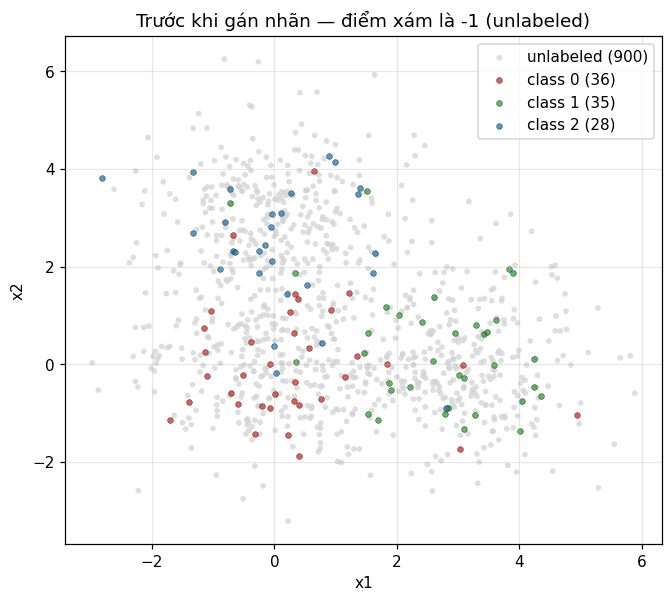

In [19]:
# Trực quan trạng thái BAN ĐẦU: -1 (xám) là chưa có nhãn
color_map = {-1: 'lightgray', 0: 'tab:red', 1: 'tab:green', 2: 'tab:blue'}
label_map = {-1: 'unlabeled', 0: 'class 0', 1: 'class 1', 2: 'class 2'}

fig, ax = plt.subplots(figsize=(7, 6))
for lab in [-1, 0, 1, 2]:
    mask = dp.y == lab
    ax.scatter(dp.X[mask, 0], dp.X[mask, 1], s=14, c=color_map[lab],
               label=f'{label_map[lab]} ({mask.sum()})', alpha=0.75,
               edgecolor='k' if lab != -1 else 'none', linewidth=0.3)
ax.set_title('Trước khi gán nhãn — điểm xám là -1 (unlabeled)')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 1.5. Chọn K bằng phương pháp Elbow

K = số tâm K-Means = số nơ-ron lớp ẩn RBF. Chọn K dữ liệu thay vì gán cứng: chạy K-Means cho mỗi giá trị $K$ trong dải khảo sát, tính **WCSS** (within-cluster sum of squares = inertia):

$$\text{WCSS}(K)=\sum_{k=1}^{K}\sum_{x\in C_k}\lVert x-\mu_k\rVert^2$$

WCSS luôn giảm khi tăng $K$, nhưng tốc độ giảm chậm dần. Điểm **"gãy khuỷu tay"** (elbow) — nơi đường cong chuyển từ dốc sang phẳng — là $K$ hợp lý: thêm tâm sau đó không cải thiện đáng kể.

In [20]:
from sklearn.cluster import KMeans

K_range = range(2, 21)
wcss = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(dp.X)
    wcss.append(km.inertia_)   # tổng bình phương khoảng cách tới tâm gần nhất

# Heuristic phát hiện elbow: K có khoảng cách lớn nhất tới đường thẳng nối điểm đầu-cuối
ks = np.array(list(K_range)); ws = np.array(wcss)
p1, p2 = np.array([ks[0], ws[0]]), np.array([ks[-1], ws[-1]])
line_unit = (p2 - p1) / np.linalg.norm(p2 - p1)
points = np.column_stack([ks, ws]) - p1
proj = points @ line_unit                          # hình chiếu lên đường thẳng
perp = points - np.outer(proj, line_unit)          # thành phần vuông góc
dists = np.linalg.norm(perp, axis=1)               # khoảng cách vuông góc
K_elbow = int(ks[np.argmax(dists)])
print(f'Elbow đề xuất K = {K_elbow}')

Elbow đề xuất K = 6


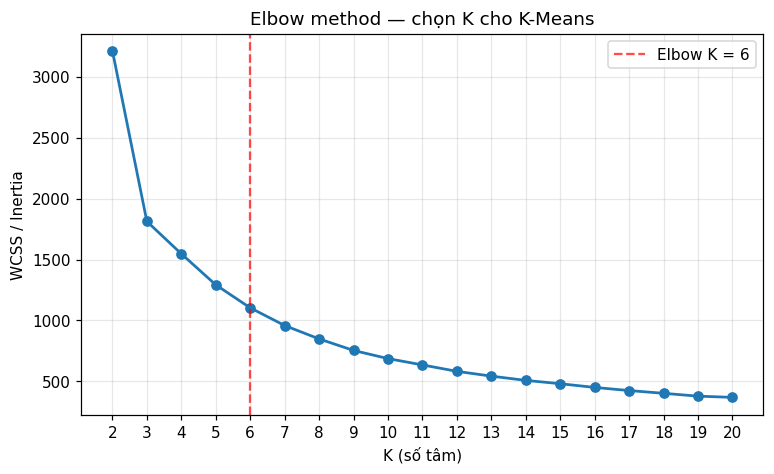

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(K_range), wcss, marker='o', linewidth=1.8)
ax.axvline(K_elbow, color='red', linestyle='--', alpha=0.7,
           label=f'Elbow K = {K_elbow}')
ax.set_xlabel('K (số tâm)'); ax.set_ylabel('WCSS / Inertia')
ax.set_title('Elbow method — chọn K cho K-Means')
ax.set_xticks(list(K_range)); ax.legend(); ax.grid(alpha=0.3)
plt.show()

**Nhận xét.** Elbow chỉ ra số cụm "tự nhiên" của dữ liệu (3 vùng class lớn, nhưng phương sai trong từng class đẩy elbow lên cao hơn 3). Vì $K$ trong RBF Network cũng đóng vai trò *số nơ-ron lớp ẩn*, ta lấy luôn `K_elbow` làm số tâm cho các bước phía dưới — đảm bảo lựa chọn dựa trên dữ liệu, không hard-code.

## 2. Lớp ẩn RBF: K-Means + Gaussian

Chạy K-Means trên **toàn bộ** dữ liệu (cả labeled và unlabeled). Heuristic độ trải: $\sigma = d_{\max}/\sqrt{2K}$ — đảm bảo các Gaussian phủ lẫn nhau.

In [22]:
K = K_elbow  # số tâm RBF (số nơ-ron lớp ẩn) lấy từ Elbow ở cell trên
rbf = RBFLayer(n_centers=K, random_state=42).fit(dp.X)
print(f'Số tâm K = {K}')
print(f'σ (spread) = {rbf.sigma:.4f}')
print('Tọa độ tâm (đầu):')
print(rbf.centers[:5])

Số tâm K = 6
σ (spread) = 1.5887
Tọa độ tâm (đầu):
[[ 3.44239379 -0.63878005]
 [ 0.02451334  3.67455841]
 [ 1.15119828 -0.43231918]
 [-0.14757247  1.87578105]
 [-0.79708959 -0.25893782]]


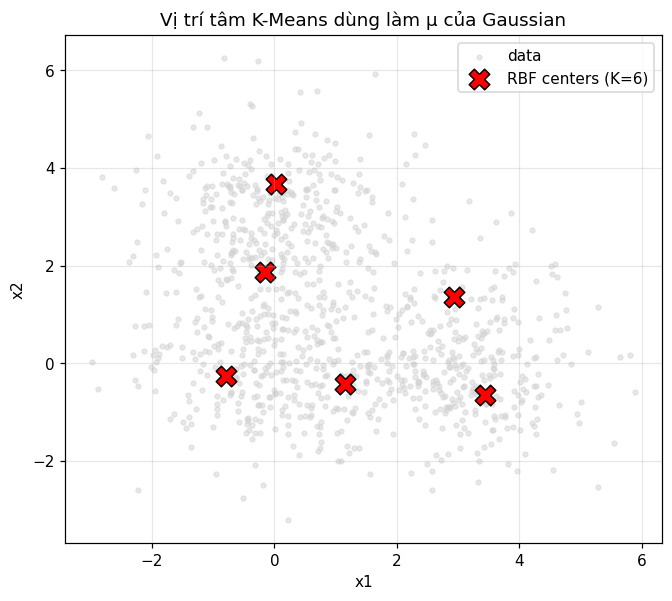

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(dp.X[:, 0], dp.X[:, 1], s=10, c='lightgray', alpha=0.5, label='data')
ax.scatter(rbf.centers[:, 0], rbf.centers[:, 1], s=180, c='red',
           marker='X', edgecolor='k', label=f'RBF centers (K={K})')
ax.set_title('Vị trí tâm K-Means dùng làm μ của Gaussian')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 3. Tối ưu trọng số W bằng PSO

Mỗi *particle* mã hoá toàn bộ ma trận $W\in\mathbb{R}^{K\times 3}$ ở dạng vector phẳng. Hàm fitness là **cross-entropy** trên `labeled_data`:

$$\mathcal L(W)=-\frac{1}{N}\sum_{i=1}^{N}\sum_{c=0}^{2} y_{ic}\,\log\bigl(\mathrm{softmax}(\Phi W)_{ic}\bigr)$$

In [24]:
net_pso = RBFNetwork(
    n_centers=K, n_classes=3, optimizer='pso',
    random_state=42,
    n_particles=40, n_iter=400, w=0.72, c1=1.49, c2=1.49,
)
net_pso.fit(dp.X, dp.X_labeled, dp.y_labeled)
print(f'PSO best cross-entropy = {net_pso.best_loss:.4f}')

PSO best cross-entropy = 0.5713


In [25]:
net_ga = RBFNetwork(
    n_centers=K, n_classes=3, optimizer='ga',
    random_state=42,
    pop_size=60, n_iter=400, mutation_rate=0.15, mutation_scale=0.25,
    elite_frac=0.1, tournament_k=3,
)
net_ga.fit(dp.X, dp.X_labeled, dp.y_labeled)
print(f'GA  best cross-entropy = {net_ga.best_loss:.4f}')

GA  best cross-entropy = 0.5713


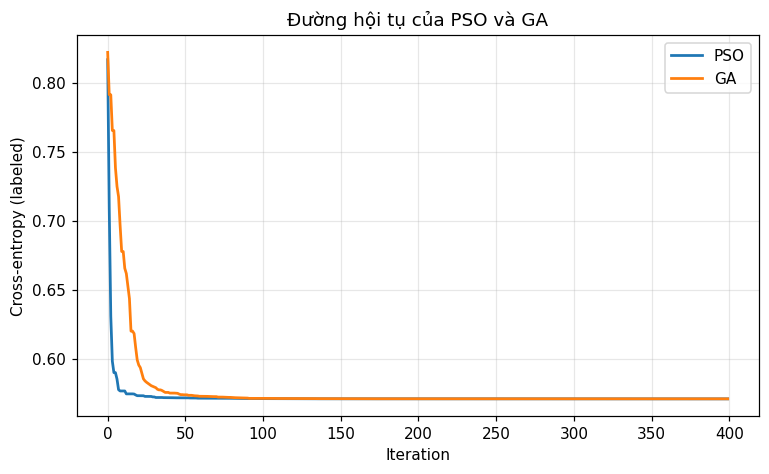

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(net_pso.optimizer.history, label='PSO', linewidth=1.8)
ax.plot(net_ga.optimizer.history,  label='GA',  linewidth=1.8)
ax.set_xlabel('Iteration'); ax.set_ylabel('Cross-entropy (labeled)')
ax.set_title('Đường hội tụ của PSO và GA')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [27]:
# Chọn bộ tốt hơn giữa PSO và GA để dùng cho inference
best_net = net_pso if net_pso.best_loss <= net_ga.best_loss else net_ga
print(f'-> Mô hình được chọn: {best_net.optimizer_name.upper()} '
      f'(loss = {best_net.best_loss:.4f})')

# Train accuracy trên labeled
pred_lab = best_net.predict(dp.X_labeled)
train_acc = (pred_lab == dp.y_labeled).mean()
print(f'Accuracy trên labeled set: {train_acc:.4f}')

-> Mô hình được chọn: PSO (loss = 0.5713)
Accuracy trên labeled set: 0.7980


## 4. Inference & gán nhãn tự động

* **(a) Relabel toàn bộ:** dùng RBF dự đoán cho mọi điểm — thử nghiệm xem model phân vùng thế nào.
* **(b) Giữ nguyên class gốc, chỉ điền cho -1:** chỉ thay nhãn ở những điểm chưa có. **Yêu cầu chính** của đề.

In [28]:
# (a) gán lại toàn bộ
y_relabel_all = best_net.predict(dp.X)

# (b) chỉ điền -1
y_filled = dp.y.copy()
y_filled[dp.unlabeled_mask] = best_net.predict(dp.X_unlabeled)

print('Phân bố sau (a) relabel toàn bộ :', dict(zip(*np.unique(y_relabel_all, return_counts=True))))
print('Phân bố sau (b) chỉ điền -1     :', dict(zip(*np.unique(y_filled,     return_counts=True))))

Phân bố sau (a) relabel toàn bộ : {np.int64(0): np.int64(306), np.int64(1): np.int64(363), np.int64(2): np.int64(330)}
Phân bố sau (b) chỉ điền -1     : {np.int64(0): np.int64(312), np.int64(1): np.int64(359), np.int64(2): np.int64(328)}


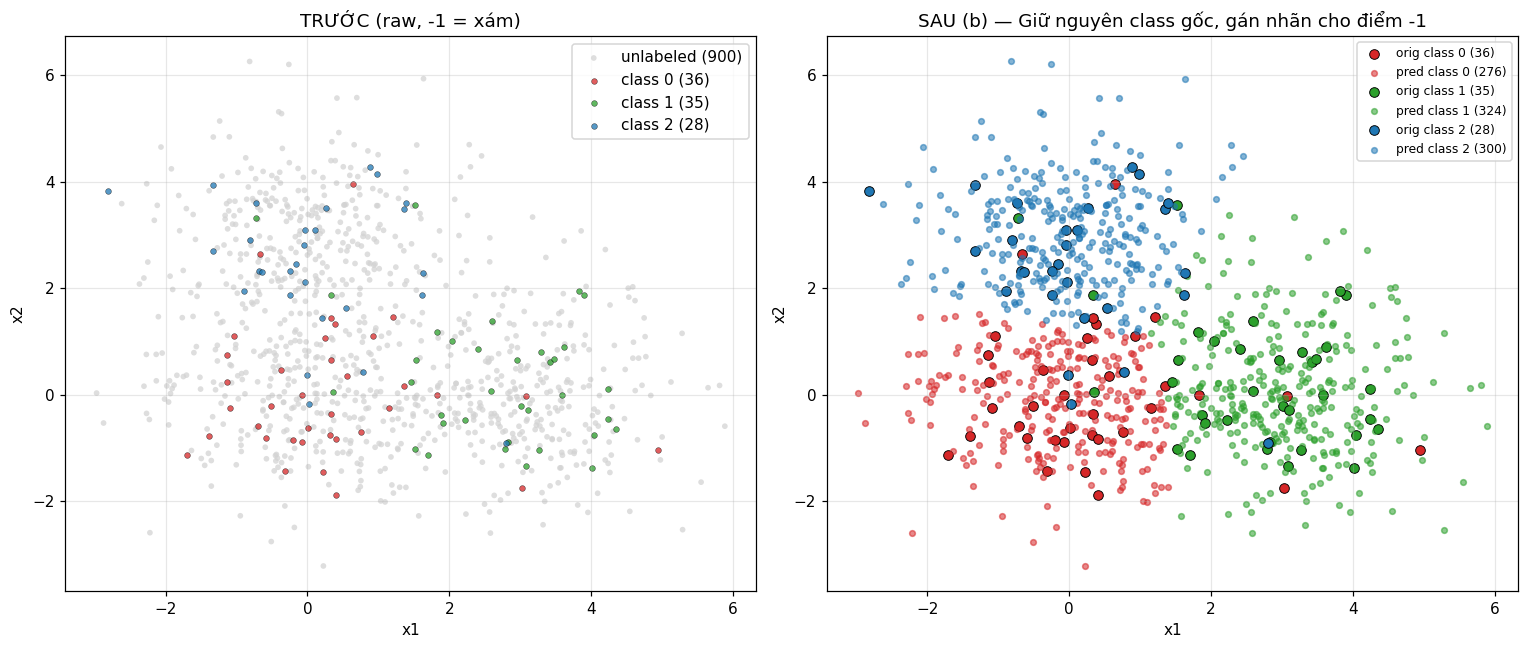

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trước
ax = axes[0]
for lab in [-1, 0, 1, 2]:
    mask = dp.y == lab
    ax.scatter(dp.X[mask, 0], dp.X[mask, 1], s=14, c=color_map[lab],
               label=f'{label_map[lab]} ({mask.sum()})', alpha=0.75,
               edgecolor='k' if lab != -1 else 'none', linewidth=0.3)
ax.set_title('TRƯỚC (raw, -1 = xám)')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(); ax.grid(alpha=0.3)

# Sau (b): giữ nguyên class gốc, chỉ điền -1
ax = axes[1]
after_color = {0: 'tab:red', 1: 'tab:green', 2: 'tab:blue'}
for lab in [0, 1, 2]:
    mask_orig = (dp.y == lab)
    mask_pred = (dp.unlabeled_mask) & (y_filled == lab)
    ax.scatter(dp.X[mask_orig, 0], dp.X[mask_orig, 1], s=40, c=after_color[lab],
               edgecolor='k', linewidth=0.6,
               label=f'orig class {lab} ({mask_orig.sum()})')
    ax.scatter(dp.X[mask_pred, 0], dp.X[mask_pred, 1], s=14, c=after_color[lab],
               alpha=0.55, label=f'pred class {lab} ({mask_pred.sum()})')
ax.set_title('SAU (b) — Giữ nguyên class gốc, gán nhãn cho điểm -1')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

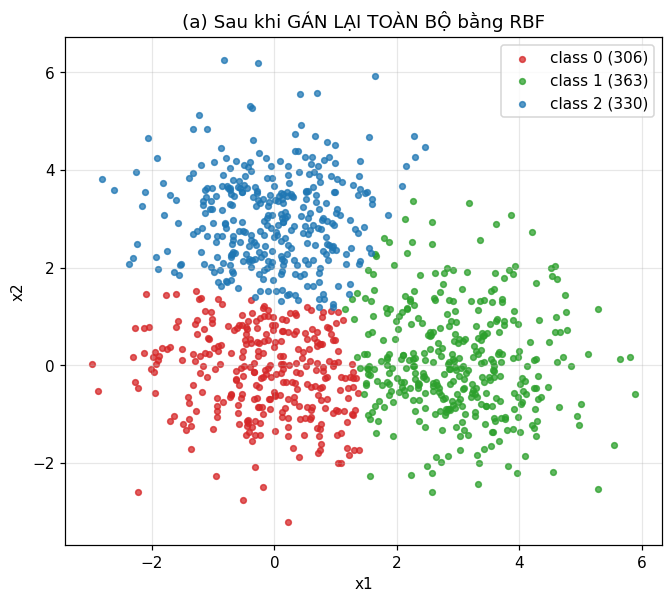

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
for lab in [0, 1, 2]:
    mask = (y_relabel_all == lab)
    ax.scatter(dp.X[mask, 0], dp.X[mask, 1], s=14, c=after_color[lab],
               label=f'class {lab} ({mask.sum()})', alpha=0.75)
ax.set_title('(a) Sau khi GÁN LẠI TOÀN BỘ bằng RBF')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 5. Vùng quyết định (decision regions)
Vẽ heatmap cho thấy mạng RBF phân chia mặt phẳng $(x_1, x_2)$ ra sao.

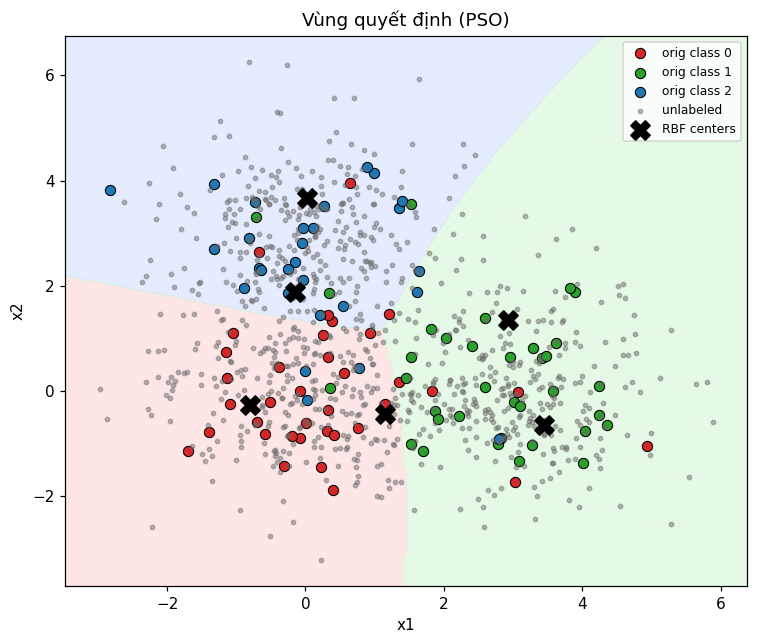

In [31]:
x_min, x_max = dp.X[:, 0].min() - 0.5, dp.X[:, 0].max() + 0.5
y_min, y_max = dp.X[:, 1].min() - 0.5, dp.X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = best_net.predict(grid).reshape(xx.shape)

from matplotlib.colors import ListedColormap
cmap_bg = ListedColormap(['#ffd6d6', '#d6f5d6', '#d6e0ff'])

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.contourf(xx, yy, Z, alpha=0.6, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5, 2.5])
for lab in [0, 1, 2]:
    mask = dp.y == lab
    ax.scatter(dp.X[mask, 0], dp.X[mask, 1], s=45, c=after_color[lab],
               edgecolor='k', linewidth=0.7, label=f'orig class {lab}')
ax.scatter(dp.X[dp.unlabeled_mask, 0], dp.X[dp.unlabeled_mask, 1],
           s=8, c='dimgray', alpha=0.45, label='unlabeled')
ax.scatter(best_net.rbf.centers[:, 0], best_net.rbf.centers[:, 1],
           s=160, marker='X', c='black', label='RBF centers')
ax.set_title(f'Vùng quyết định ({best_net.optimizer_name.upper()})')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(loc='best', fontsize=8)
plt.show()

## 6. Lưu kết quả ra CSV

In [32]:
out_b = dp.df.copy(); out_b['label'] = y_filled
out_b.to_csv('result_keep_original.csv', index=False)

out_a = dp.df.copy(); out_a['label'] = y_relabel_all
out_a.to_csv('result_relabel_all.csv', index=False)

print('Đã ghi: result_keep_original.csv, result_relabel_all.csv')

Đã ghi: result_keep_original.csv, result_relabel_all.csv
